<a href="https://colab.research.google.com/github/Roshanraj2580/Rice_Leaf_Detection/blob/main/Resnet50.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    roc_curve,
    auc,
    roc_auc_score
)
from sklearn.preprocessing import label_binarize


In [3]:
import os

print("Train exists:", os.path.exists("/content/drive/MyDrive/Minor_Project/Data/Splitted_Strict/train"))
print("Val exists  :", os.path.exists("/content/drive/MyDrive/Minor_Project/Data/Splitted_Strict/val"))
print("Test exists :", os.path.exists("/content/drive/MyDrive/Minor_Project/Data/Splitted_Strict/test"))


Train exists: True
Val exists  : True
Test exists : True


In [4]:
import os

# Dataset paths
train_dir = "/content/drive/MyDrive/Minor_Project/Data/Splitted_Strict/train"
val_dir = "/content/drive/MyDrive/Minor_Project/Data/Splitted_Strict/val"
test_dir = "/content/drive/MyDrive/Minor_Project/Data/Splitted_Strict/test"

# Model save directory
model_dir = "/content/drive/MyDrive/Minor_Project/Models/ResNet 50"
os.makedirs(model_dir, exist_ok=True)

model_path = os.path.join(model_dir, "resnet50_rice_leaf_model.keras")

# Results save directory
results_dir = os.path.join(model_dir, "results")
os.makedirs(results_dir, exist_ok=True)

# Parameters
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 1
LEARNING_RATE = 0.0001

print("Paths and parameters loaded.")


Paths and parameters loaded.


In [5]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    shear_range=0.10,
    zoom_range=0.10,
    horizontal_flip=True,
    fill_mode="nearest"
)

val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

class_names = list(train_generator.class_indices.keys())
num_classes = len(class_names)

print("Classes:", class_names)


Found 1739 images belonging to 4 classes.
Found 367 images belonging to 4 classes.
Found 340 images belonging to 4 classes.
Classes: ['Bacterialblight', 'Blast', 'Brownspot', 'Tungro']


In [6]:
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

for layer in base_model.layers:
    layer.trainable = False

x = GlobalAveragePooling2D()(base_model.output)
x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)
output = Dense(num_classes, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,113,284 (91.98 MB)

 Trainable params: 525,572 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [7]:
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=model_path,
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    )
]

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=callbacks
)

print("Model saved at:", model_path)


55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.4499 - loss: 1.5161
Epoch 1: val_accuracy improved from None to 0.87466, saving model to /content/drive/MyDrive/Minor_Project/Models/ResNet 50/resnet50_rice_leaf_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Minor_Project/Models/ResNet 50/resnet50_rice_leaf_model.keras
55/55 ━━━━━━━━━━━━━━━━━━━━ 704s 13s/step - accuracy: 0.6205 - loss: 1.0083 - val_accuracy: 0.8747 - val_loss: 0.4077
Restoring model weights from the end of the best epoch: 1.
Model saved at: /content/drive/MyDrive/Minor_Project/Models/ResNet 50/resnet50_rice_leaf_model.keras


In [8]:
import os

base = "/content/drive/MyDrive/Minor_Project/Data/Splitted_Strict"

for split in ["train", "val", "test"]:
    print(f"\n{split.upper()}")
    split_path = os.path.join(base, split)
    for cls in sorted(os.listdir(split_path)):
        cls_path = os.path.join(split_path, cls)
        if os.path.isdir(cls_path):
            count = len(os.listdir(cls_path))
            print(f"{cls}: {count}")



TRAIN
Bacterialblight: 305
Blast: 323
Brownspot: 606
Tungro: 505

VAL
Bacterialblight: 206
Blast: 1
Brownspot: 4
Tungro: 156

TEST
Bacterialblight: 4
Blast: 160
Brownspot: 4
Tungro: 172


In [9]:

best_model = load_model(model_path)
print("Loaded model from:", model_path)


Loaded model from: /content/drive/MyDrive/Minor_Project/Models/ResNet 50/resnet50_rice_leaf_model.keras


In [10]:
train_loss, train_acc = best_model.evaluate(train_generator, verbose=1)
val_loss, val_acc = best_model.evaluate(val_generator, verbose=1)
test_loss, test_acc = best_model.evaluate(test_generator, verbose=1)

print("\nCore Metrics")
print(f"Train Accuracy      : {train_acc:.4f}")
print(f"Validation Accuracy : {val_acc:.4f}")
print(f"Test Accuracy       : {test_acc:.4f}")
print(f"Train Loss          : {train_loss:.4f}")
print(f"Validation Loss     : {val_loss:.4f}")
print(f"Test Loss           : {test_loss:.4f}")


55/55 ━━━━━━━━━━━━━━━━━━━━ 363s 7s/step - accuracy: 0.8562 - loss: 0.3828
12/12 ━━━━━━━━━━━━━━━━━━━━ 71s 6s/step - accuracy: 0.8747 - loss: 0.4077
11/11 ━━━━━━━━━━━━━━━━━━━━ 192s 19s/step - accuracy: 0.7294 - loss: 0.5291

Core Metrics
Train Accuracy      : 0.8562
Validation Accuracy : 0.8747
Test Accuracy       : 0.7294
Train Loss          : 0.3828
Validation Loss     : 0.4077
Test Loss           : 0.5291


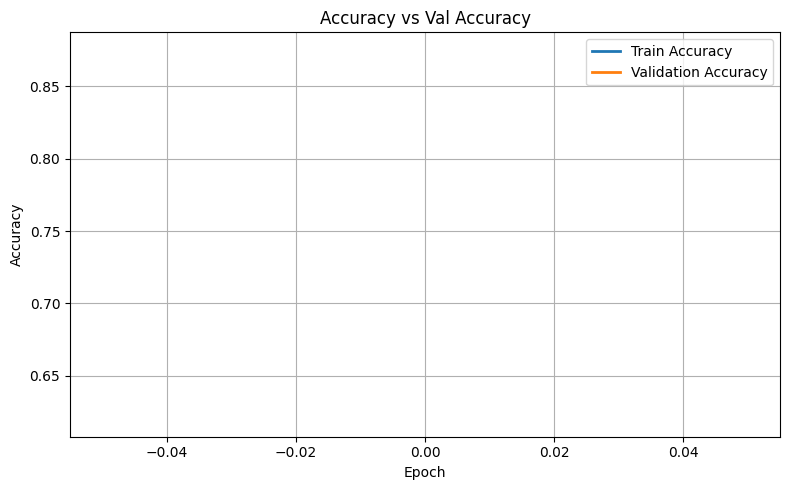

Saved: /content/drive/MyDrive/Minor_Project/Models/ResNet 50/results/accuracy_vs_val_accuracy.png


In [11]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Train Accuracy", linewidth=2)
plt.plot(history.history["val_accuracy"], label="Validation Accuracy", linewidth=2)
plt.title("Accuracy vs Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()

acc_plot_path = os.path.join(results_dir, "accuracy_vs_val_accuracy.png")
plt.savefig(acc_plot_path, dpi=300)
plt.show()

print("Saved:", acc_plot_path)


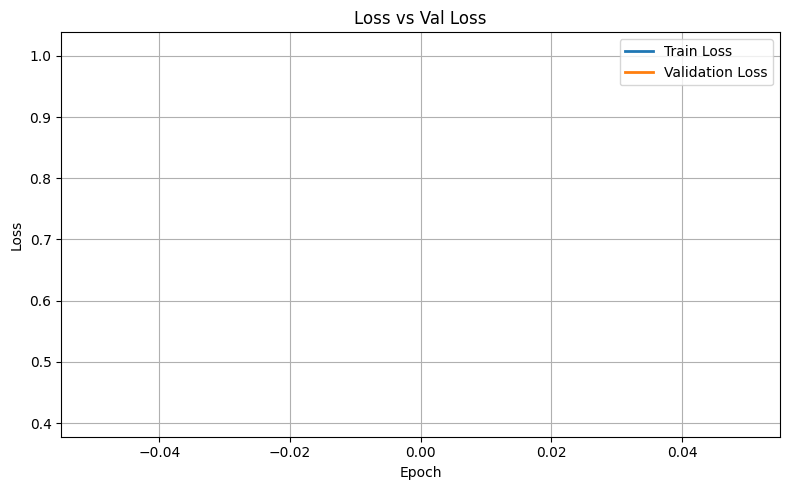

Saved: /content/drive/MyDrive/Minor_Project/Models/ResNet 50/results/loss_vs_val_loss.png


In [12]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Train Loss", linewidth=2)
plt.plot(history.history["val_loss"], label="Validation Loss", linewidth=2)
plt.title("Loss vs Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()

loss_plot_path = os.path.join(results_dir, "loss_vs_val_loss.png")
plt.savefig(loss_plot_path, dpi=300)
plt.show()

print("Saved:", loss_plot_path)


In [13]:
test_generator.reset()
y_prob = best_model.predict(test_generator, verbose=1)
y_pred = np.argmax(y_prob, axis=1)
y_true = test_generator.classes


11/11 ━━━━━━━━━━━━━━━━━━━━ 69s 6s/step


In [14]:
precision = precision_score(y_true, y_pred, average="weighted")
recall = recall_score(y_true, y_pred, average="weighted")
f1 = f1_score(y_true, y_pred, average="weighted")
acc = accuracy_score(y_true, y_pred)

print("\nClassification Metrics")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")
print(f"Accuracy  : {acc:.4f}")



Classification Metrics
Precision : 0.9655
Recall    : 0.7294
F1-score  : 0.7909
Accuracy  : 0.7294


In [15]:
report = classification_report(y_true, y_pred, target_names=class_names)
print("\nClassification Report\n")
print(report)

report_path = os.path.join(results_dir, "classification_report.txt")
with open(report_path, "w") as f:
    f.write(report)

print("Saved:", report_path)



Classification Report

                 precision    recall  f1-score   support

Bacterialblight       0.07      0.75      0.13         4
          Blast       0.99      0.44      0.61       160
      Brownspot       0.06      0.75      0.11         4
         Tungro       0.99      1.00      0.99       172

       accuracy                           0.73       340
      macro avg       0.53      0.73      0.46       340
   weighted avg       0.97      0.73      0.79       340

Saved: /content/drive/MyDrive/Minor_Project/Models/ResNet 50/results/classification_report.txt


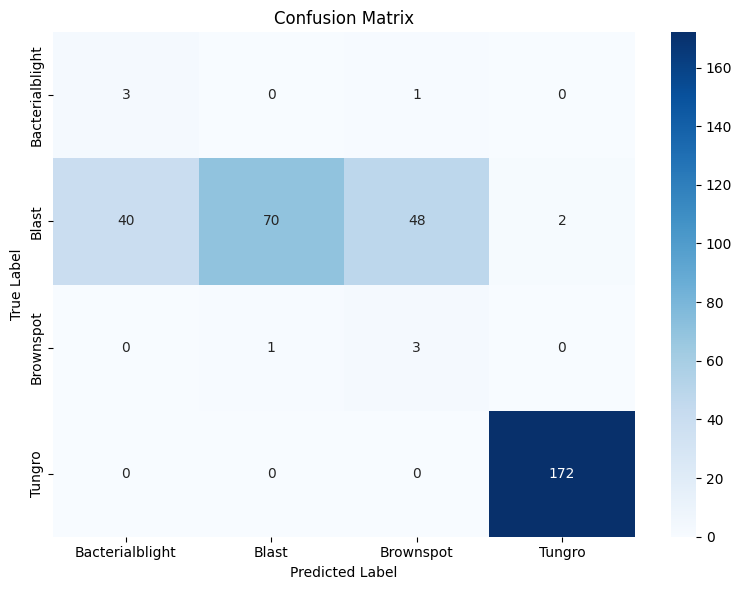

Saved: /content/drive/MyDrive/Minor_Project/Models/ResNet 50/results/confusion_matrix.png


In [16]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()

cm_path = os.path.join(results_dir, "confusion_matrix.png")
plt.savefig(cm_path, dpi=300)
plt.show()

print("Saved:", cm_path)


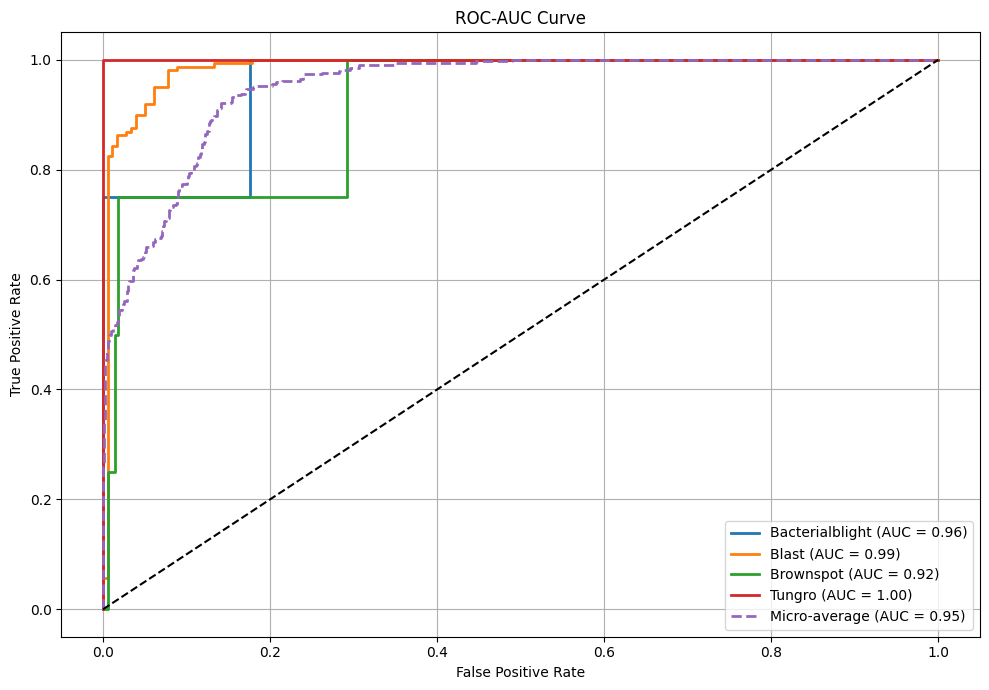

Saved: /content/drive/MyDrive/Minor_Project/Models/ResNet 50/results/roc_auc_curve.png


In [17]:

y_true_bin = label_binarize(y_true, classes=np.arange(num_classes))

fpr = {}
tpr = {}
roc_auc = {}

plt.figure(figsize=(10, 7))

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], linewidth=2, label=f"{class_names[i]} (AUC = {roc_auc[i]:.2f})")

fpr_micro, tpr_micro, _ = roc_curve(y_true_bin.ravel(), y_prob.ravel())
roc_auc_micro = auc(fpr_micro, tpr_micro)

plt.plot(fpr_micro, tpr_micro, linestyle="--", linewidth=2, label=f"Micro-average (AUC = {roc_auc_micro:.2f})")
plt.plot([0, 1], [0, 1], "k--")
plt.title("ROC-AUC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.tight_layout()

roc_path = os.path.join(results_dir, "roc_auc_curve.png")
plt.savefig(roc_path, dpi=300)
plt.show()

print("Saved:", roc_path)


In [18]:
roc_auc_macro = roc_auc_score(y_true_bin, y_prob, multi_class="ovr", average="macro")
roc_auc_weighted = roc_auc_score(y_true_bin, y_prob, multi_class="ovr", average="weighted")

print("\nROC-AUC Scores")
print(f"Macro ROC-AUC    : {roc_auc_macro:.4f}")
print(f"Weighted ROC-AUC : {roc_auc_weighted:.4f}")



ROC-AUC Scores
Macro ROC-AUC    : 0.9649
Weighted ROC-AUC : 0.9920


In [19]:


metrics_dict = {
    "train_accuracy": float(train_acc),
    "validation_accuracy": float(val_acc),
    "test_accuracy": float(test_acc),
    "train_loss": float(train_loss),
    "validation_loss": float(val_loss),
    "test_loss": float(test_loss),
    "precision_weighted": float(precision),
    "recall_weighted": float(recall),
    "f1_score_weighted": float(f1),
    "test_accuracy_sklearn": float(acc),
    "roc_auc_macro": float(roc_auc_macro),
    "roc_auc_weighted": float(roc_auc_weighted)
}

metrics_path = os.path.join(results_dir, "metrics.json")
with open(metrics_path, "w") as f:
    json.dump(metrics_dict, f, indent=4)

print("Saved:", metrics_path)


Saved: /content/drive/MyDrive/Minor_Project/Models/ResNet 50/results/metrics.json


In [20]:
summary_path = os.path.join(results_dir, "final_metrics_summary.txt")

with open(summary_path, "w") as f:
    f.write("Final Evaluation Metrics\n")
    f.write("========================\n\n")
    f.write(f"Train Accuracy      : {train_acc:.4f}\n")
    f.write(f"Validation Accuracy : {val_acc:.4f}\n")
    f.write(f"Test Accuracy       : {test_acc:.4f}\n")
    f.write(f"Train Loss          : {train_loss:.4f}\n")
    f.write(f"Validation Loss     : {val_loss:.4f}\n")
    f.write(f"Test Loss           : {test_loss:.4f}\n")
    f.write(f"Precision           : {precision:.4f}\n")
    f.write(f"Recall              : {recall:.4f}\n")
    f.write(f"F1-score            : {f1:.4f}\n")
    f.write(f"Accuracy            : {acc:.4f}\n")
    f.write(f"Macro ROC-AUC       : {roc_auc_macro:.4f}\n")
    f.write(f"Weighted ROC-AUC    : {roc_auc_weighted:.4f}\n")

print("Saved:", summary_path)
print("\nAll results saved in:", results_dir)


Saved: /content/drive/MyDrive/Minor_Project/Models/ResNet 50/results/final_metrics_summary.txt

All results saved in: /content/drive/MyDrive/Minor_Project/Models/ResNet 50/results


In [21]:
!pip install gradio


In [22]:

import gradio as gr
import numpy as np
import tensorflow as tf
from PIL import Image
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.resnet50 import preprocess_input


In [23]:
model_path = "/content/drive/MyDrive/Minor_Project/Models/ResNet 50/resnet50_rice_leaf_model.keras"
model = load_model(model_path)

print("Model loaded successfully.")


Model loaded successfully.


In [24]:
class_names = ['Bacterialblight', 'Blast', 'Brownspot', 'Tungro']


In [25]:
def predict_rice_leaf(img):
    if img is None:
        return "No image uploaded.", {}

    img = img.convert("RGB")
    img = img.resize((224, 224))

    img_array = np.array(img, dtype=np.float32)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)

    preds = model.predict(img_array)[0]
    predicted_index = np.argmax(preds)
    predicted_class = class_names[predicted_index]
    confidence = float(preds[predicted_index]) * 100

    if confidence >= 90:
        analysis = "High confidence prediction."
    elif confidence >= 70:
        analysis = "Moderate confidence prediction."
    else:
        analysis = "Low confidence prediction. Please verify with more samples."

    result_text = (
        f"Predicted Disease: {predicted_class}\n"
        f"Confidence: {confidence:.2f}%\n"
        f"Analysis: {analysis}"
    )

    prob_dict = {class_names[i]: float(preds[i]) for i in range(len(class_names))}
    return result_text, prob_dict


In [26]:

interface = gr.Interface(
    fn=predict_rice_leaf,
    inputs=gr.Image(type="pil", label="Upload Rice Leaf Image"),
    outputs=[
        gr.Textbox(label="Prediction Result"),
        gr.Label(label="Prediction Confidence")
    ],
    title="Rice Leaf Disease Detector",
    description="Upload a rice leaf image and the model will predict the disease category.",
    theme="default"
)


In [27]:
interface.launch(share=True)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://c896382621046b90ad.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Results will be saved in: /content/drive/MyDrive/Minor_Project/Models/ResNet 50/results
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
55/55 ━━━━━━━━━━━━━━━━━━━━ 368s 7s/step - accuracy: 0.8677 - loss: 0.3775
12/12 ━━━━━━━━━━━━━━━━━━━━ 70s 6s/step - accuracy: 0.8747 - loss: 0.4077
11/11 ━━━━━━━━━━━━━━━━━━━━ 65s 6s/step - accuracy: 0.7294 - loss: 0.5291

Core Metrics
Train Accuracy      : 0.8677
Validation Accuracy : 0.8747
Test Accuracy       : 0.7294
Train Loss          : 0.3775
Validation Loss     : 0.4077
Test Loss           : 0.5291


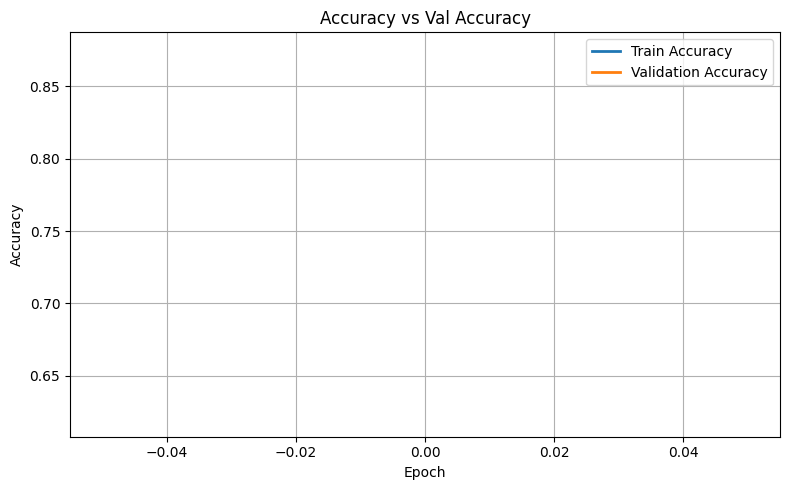

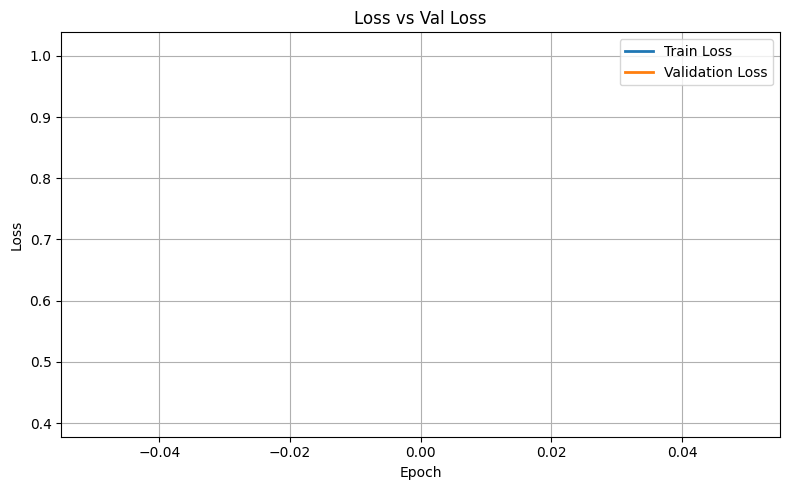

11/11 ━━━━━━━━━━━━━━━━━━━━ 65s 6s/step

Classification Metrics
Precision : 0.9655
Recall    : 0.7294
F1-score  : 0.7909
Accuracy  : 0.7294

Classification Report

                 precision    recall  f1-score   support

Bacterialblight       0.07      0.75      0.13         4
          Blast       0.99      0.44      0.61       160
      Brownspot       0.06      0.75      0.11         4
         Tungro       0.99      1.00      0.99       172

       accuracy                           0.73       340
      macro avg       0.53      0.73      0.46       340
   weighted avg       0.97      0.73      0.79       340



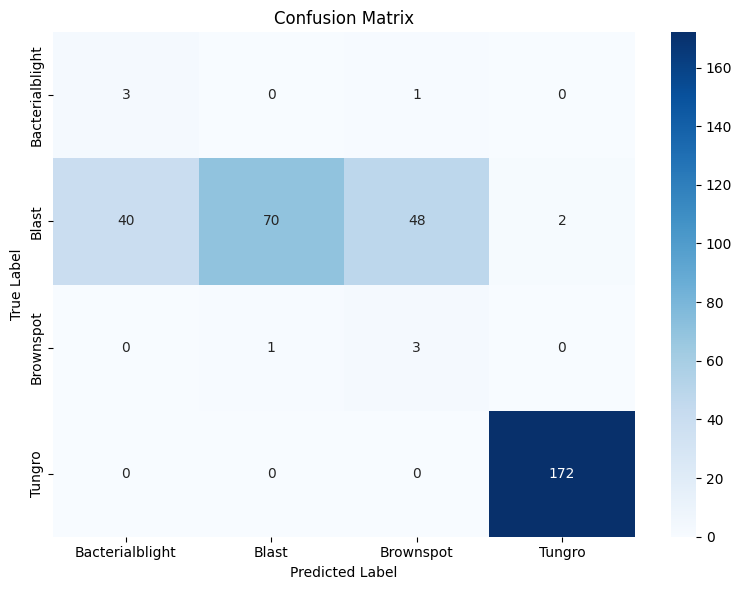

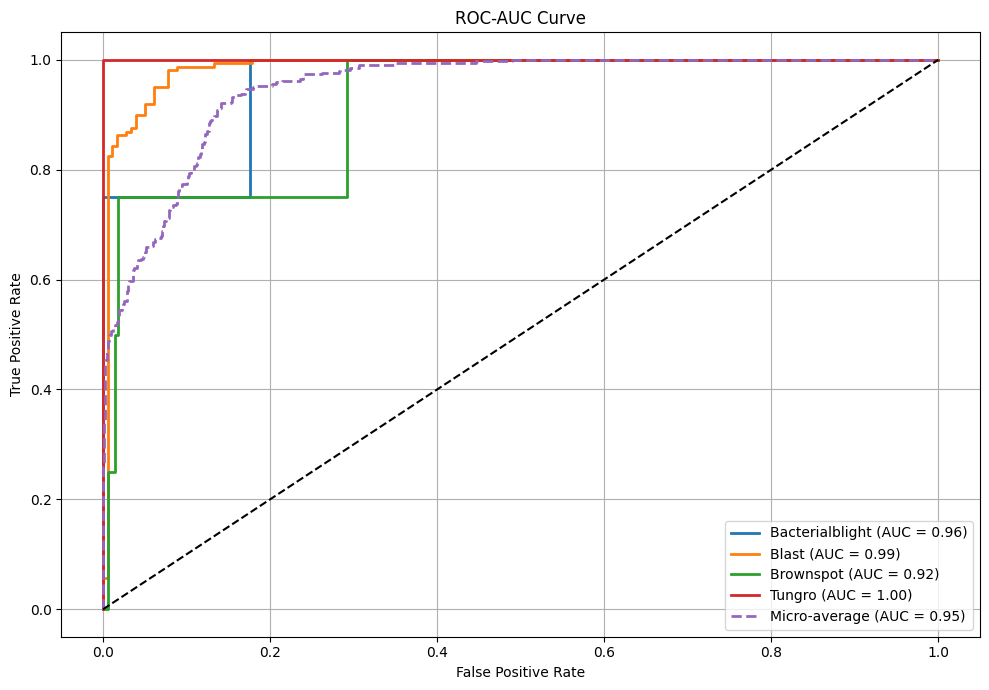


ROC-AUC Scores
Macro ROC-AUC    : 0.9649
Weighted ROC-AUC : 0.9920

Saved Files:
/content/drive/MyDrive/Minor_Project/Models/ResNet 50/results/accuracy_vs_val_accuracy.png
/content/drive/MyDrive/Minor_Project/Models/ResNet 50/results/loss_vs_val_loss.png
/content/drive/MyDrive/Minor_Project/Models/ResNet 50/results/classification_report.txt
/content/drive/MyDrive/Minor_Project/Models/ResNet 50/results/confusion_matrix.png
/content/drive/MyDrive/Minor_Project/Models/ResNet 50/results/roc_auc_curve.png
/content/drive/MyDrive/Minor_Project/Models/ResNet 50/results/metrics.json
/content/drive/MyDrive/Minor_Project/Models/ResNet 50/results/final_metrics_summary.txt

All ResNet50 metrics and plots saved successfully.


In [28]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    roc_curve,
    auc,
    roc_auc_score
)
from sklearn.preprocessing import label_binarize

# =========================
# Results folder
# =========================
results_dir = "/content/drive/MyDrive/Minor_Project/Models/ResNet 50/results"
os.makedirs(results_dir, exist_ok=True)

print("Results will be saved in:", results_dir)

# =========================
# Core Metrics
# =========================
train_loss, train_acc = best_model.evaluate(train_generator, verbose=1)
val_loss, val_acc = best_model.evaluate(val_generator, verbose=1)
test_loss, test_acc = best_model.evaluate(test_generator, verbose=1)

print("\nCore Metrics")
print(f"Train Accuracy      : {train_acc:.4f}")
print(f"Validation Accuracy : {val_acc:.4f}")
print(f"Test Accuracy       : {test_acc:.4f}")
print(f"Train Loss          : {train_loss:.4f}")
print(f"Validation Loss     : {val_loss:.4f}")
print(f"Test Loss           : {test_loss:.4f}")

# =========================
# Accuracy Plot
# =========================
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Train Accuracy", linewidth=2)
plt.plot(history.history["val_accuracy"], label="Validation Accuracy", linewidth=2)
plt.title("Accuracy vs Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()

acc_plot_path = os.path.join(results_dir, "accuracy_vs_val_accuracy.png")
plt.savefig(acc_plot_path, dpi=300)
plt.show()

# =========================
# Loss Plot
# =========================
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Train Loss", linewidth=2)
plt.plot(history.history["val_loss"], label="Validation Loss", linewidth=2)
plt.title("Loss vs Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()

loss_plot_path = os.path.join(results_dir, "loss_vs_val_loss.png")
plt.savefig(loss_plot_path, dpi=300)
plt.show()

# =========================
# Predictions
# =========================
test_generator.reset()
y_prob = best_model.predict(test_generator, verbose=1)
y_pred = np.argmax(y_prob, axis=1)
y_true = test_generator.classes

# =========================
# Classification Metrics
# =========================
precision = precision_score(y_true, y_pred, average="weighted")
recall = recall_score(y_true, y_pred, average="weighted")
f1 = f1_score(y_true, y_pred, average="weighted")
acc = accuracy_score(y_true, y_pred)

print("\nClassification Metrics")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")
print(f"Accuracy  : {acc:.4f}")

# =========================
# Classification Report
# =========================
report = classification_report(y_true, y_pred, target_names=class_names)
print("\nClassification Report\n")
print(report)

report_path = os.path.join(results_dir, "classification_report.txt")
with open(report_path, "w") as f:
    f.write(report)

# =========================
# Confusion Matrix
# =========================
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()

cm_path = os.path.join(results_dir, "confusion_matrix.png")
plt.savefig(cm_path, dpi=300)
plt.show()

# =========================
# ROC-AUC Curve
# =========================
num_classes = len(class_names)
y_true_bin = label_binarize(y_true, classes=np.arange(num_classes))

fpr = {}
tpr = {}
roc_auc = {}

plt.figure(figsize=(10, 7))

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], linewidth=2, label=f"{class_names[i]} (AUC = {roc_auc[i]:.2f})")

fpr_micro, tpr_micro, _ = roc_curve(y_true_bin.ravel(), y_prob.ravel())
roc_auc_micro = auc(fpr_micro, tpr_micro)

plt.plot(fpr_micro, tpr_micro, linestyle="--", linewidth=2, label=f"Micro-average (AUC = {roc_auc_micro:.2f})")
plt.plot([0, 1], [0, 1], "k--")
plt.title("ROC-AUC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.tight_layout()

roc_path = os.path.join(results_dir, "roc_auc_curve.png")
plt.savefig(roc_path, dpi=300)
plt.show()

# =========================
# ROC-AUC Scores
# =========================
roc_auc_macro = roc_auc_score(y_true_bin, y_prob, multi_class="ovr", average="macro")
roc_auc_weighted = roc_auc_score(y_true_bin, y_prob, multi_class="ovr", average="weighted")

print("\nROC-AUC Scores")
print(f"Macro ROC-AUC    : {roc_auc_macro:.4f}")
print(f"Weighted ROC-AUC : {roc_auc_weighted:.4f}")

# =========================
# Save Metrics JSON
# =========================
metrics_dict = {
    "train_accuracy": float(train_acc),
    "validation_accuracy": float(val_acc),
    "test_accuracy": float(test_acc),
    "train_loss": float(train_loss),
    "validation_loss": float(val_loss),
    "test_loss": float(test_loss),
    "precision_weighted": float(precision),
    "recall_weighted": float(recall),
    "f1_score_weighted": float(f1),
    "test_accuracy_sklearn": float(acc),
    "roc_auc_macro": float(roc_auc_macro),
    "roc_auc_weighted": float(roc_auc_weighted)
}

metrics_path = os.path.join(results_dir, "metrics.json")
with open(metrics_path, "w") as f:
    json.dump(metrics_dict, f, indent=4)

# =========================
# Save Final Summary
# =========================
summary_path = os.path.join(results_dir, "final_metrics_summary.txt")

with open(summary_path, "w") as f:
    f.write("Final Evaluation Metrics\n")
    f.write("========================\n\n")
    f.write(f"Train Accuracy      : {train_acc:.4f}\n")
    f.write(f"Validation Accuracy : {val_acc:.4f}\n")
    f.write(f"Test Accuracy       : {test_acc:.4f}\n")
    f.write(f"Train Loss          : {train_loss:.4f}\n")
    f.write(f"Validation Loss     : {val_loss:.4f}\n")
    f.write(f"Test Loss           : {test_loss:.4f}\n")
    f.write(f"Precision           : {precision:.4f}\n")
    f.write(f"Recall              : {recall:.4f}\n")
    f.write(f"F1-score            : {f1:.4f}\n")
    f.write(f"Accuracy            : {acc:.4f}\n")
    f.write(f"Macro ROC-AUC       : {roc_auc_macro:.4f}\n")
    f.write(f"Weighted ROC-AUC    : {roc_auc_weighted:.4f}\n")

print("\nSaved Files:")
print(acc_plot_path)
print(loss_plot_path)
print(report_path)
print(cm_path)
print(roc_path)
print(metrics_path)
print(summary_path)
print("\nAll ResNet50 metrics and plots saved successfully.")


In [29]:
!pip install -q gradio

import os
import gradio as gr
import numpy as np
from PIL import Image
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.resnet50 import preprocess_input

# =========================
# Find model file automatically
# =========================
model_dir = "/content/drive/MyDrive/Minor_Project/Models/ResNet 50"

files_in_dir = os.listdir(model_dir)
print("Files in model directory:", files_in_dir)

model_file = None
for file_name in files_in_dir:
    if file_name.endswith(".keras") or file_name.endswith(".h5"):
        model_file = os.path.join(model_dir, file_name)
        break

if model_file is None:
    raise FileNotFoundError("No .keras or .h5 model file found in the ResNet 50 folder.")

print("Loading model from:", model_file)
model = load_model(model_file)
print("Model loaded successfully.")

# =========================
# Class names
# =========================
class_names = ["Bacterialblight", "Blast", "Brownspot", "Tungro"]

# =========================
# Prediction function
# =========================
def predict_rice_leaf(img):
    if img is None:
        return None, "No image uploaded.", {}

    img = img.convert("RGB")
    display_img = img.copy()
    img = img.resize((224, 224))

    img_array = np.array(img, dtype=np.float32)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)

    preds = model.predict(img_array, verbose=0)[0]

    predicted_index = int(np.argmax(preds))
    predicted_class = class_names[predicted_index]
    confidence = float(preds[predicted_index]) * 100

    if confidence >= 90:
        analysis = "High confidence prediction."
    elif confidence >= 70:
        analysis = "Moderate confidence prediction."
    else:
        analysis = "Low confidence prediction. Please verify with more samples."

    result_text = (
        f"Predicted Disease: {predicted_class}\n\n"
        f"Confidence: {confidence:.2f}%\n\n"
        f"Analysis: {analysis}"
    )

    # Only predicted class confidence
    confidence_dict = {
        predicted_class: round(confidence, 2)
    }

    return display_img, result_text, confidence_dict

# =========================
# Clear function
# =========================
def clear_outputs():
    return None, None, "", {}

# =========================
# Build app
# =========================
with gr.Blocks(theme=gr.themes.Soft(), title="Rice Leaf Disease Detector") as demo:
    gr.Markdown(
        """
        # Rice Leaf Disease Detector
        Upload a rice leaf image and the model will predict the disease category.
        """
    )

    with gr.Row():
        with gr.Column():
            input_image = gr.Image(type="pil", label="Upload Rice Leaf Image")
            submit_btn = gr.Button("Submit", variant="primary")
            clear_btn = gr.Button("Clear")

        with gr.Column():
            output_image = gr.Image(label="Uploaded Image")
            result_box = gr.Textbox(label="Prediction Result", lines=6)
            confidence_box = gr.Label(label="Prediction Confidence")

    submit_btn.click(
        fn=predict_rice_leaf,
        inputs=input_image,
        outputs=[output_image, result_box, confidence_box]
    )

    clear_btn.click(
        fn=clear_outputs,
        inputs=[],
        outputs=[input_image, output_image, result_box, confidence_box]
    )

demo.launch(share=True)


Files in model directory: ['results', 'resnet50_rice_leaf_model.keras']
Loading model from: /content/drive/MyDrive/Minor_Project/Models/ResNet 50/resnet50_rice_leaf_model.keras
Model loaded successfully.


/tmp/ipykernel_4146/61744457.py:86: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Soft(), title="Rice Leaf Disease Detector") as demo:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://2407f5443946b44d4b.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [30]:
!pip install -q gradio

import os
import gradio as gr
import numpy as np
from PIL import Image
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.resnet50 import preprocess_input

# =========================
# Find and load model
# =========================
model_dir = "/content/drive/MyDrive/Minor_Project/Models/ResNet 50"

files_in_dir = os.listdir(model_dir)
print("Files in model directory:", files_in_dir)

model_file = None
for file_name in files_in_dir:
    if file_name.endswith(".keras") or file_name.endswith(".h5"):
        model_file = os.path.join(model_dir, file_name)
        break

if model_file is None:
    raise FileNotFoundError("No .keras or .h5 model file found in the ResNet 50 folder.")

print("Loading model from:", model_file)
model = load_model(model_file)
print("Model loaded successfully.")

# =========================
# Class names
# =========================
class_names = ["Bacterialblight", "Blast", "Brownspot", "Tungro"]

# =========================
# Prediction function
# =========================
def predict_rice_leaf(img):
    if img is None:
        return None, "<p style='color:red;'>No image uploaded.</p>", "<p>No prediction available.</p>"

    img = img.convert("RGB")
    display_img = img.copy()
    img = img.resize((224, 224))

    img_array = np.array(img, dtype=np.float32)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)

    preds = model.predict(img_array, verbose=0)[0]

    predicted_index = int(np.argmax(preds))
    predicted_class = class_names[predicted_index]
    confidence = float(preds[predicted_index]) * 100

    if confidence >= 90:
        analysis = "High confidence prediction."
        color = "#16a34a"
    elif confidence >= 70:
        analysis = "Moderate confidence prediction."
        color = "#f59e0b"
    else:
        analysis = "Low confidence prediction. Please verify with more samples."
        color = "#dc2626"

    result_html = f"""
    <div style="
        background:#1f1f1f;
        padding:18px;
        border-radius:14px;
        border:1px solid #333;
        color:white;
        font-family:Arial;
    ">
        <h2 style="margin:0 0 10px 0; color:#f97316;">Prediction Result</h2>
        <p style="font-size:20px; margin:8px 0;"><b>Predicted Disease:</b> {predicted_class}</p>
        <p style="font-size:18px; margin:8px 0;"><b>Confidence:</b> {confidence:.2f}%</p>
        <p style="font-size:16px; margin:8px 0; color:{color};"><b>Analysis:</b> {analysis}</p>
    </div>
    """

    bars_html = """
    <div style="
        background:#1f1f1f;
        padding:18px;
        border-radius:14px;
        border:1px solid #333;
        color:white;
        font-family:Arial;
    ">
        <h2 style="margin:0 0 15px 0; color:#f97316;">Class Confidence</h2>
    """

    for i, cls in enumerate(class_names):
        pct = float(preds[i]) * 100
        bars_html += f"""
        <div style="margin-bottom:14px;">
            <div style="display:flex; justify-content:space-between; margin-bottom:4px;">
                <span>{cls}</span>
                <span>{pct:.2f}%</span>
            </div>
            <div style="background:#333; border-radius:8px; height:14px; overflow:hidden;">
                <div style="
                    width:{pct:.2f}%;
                    background:#f97316;
                    height:14px;
                    border-radius:8px;
                "></div>
            </div>
        </div>
        """

    bars_html += "</div>"

    return display_img, result_html, bars_html

# =========================
# Clear function
# =========================
def clear_outputs():
    return None, "", ""

# =========================
# Attractive UI
# =========================
with gr.Blocks(theme=gr.themes.Soft(), title="Rice Leaf Disease Detector") as demo:
    gr.Markdown(
        """
        <div style="text-align:center;">
            <h1 style="color:#f97316;">Rice Leaf Disease Detector</h1>
            <p style="font-size:18px;">
                Upload a rice leaf image to predict the disease category with confidence percentage.
            </p>
        </div>
        """
    )

    with gr.Row():
        with gr.Column(scale=1):
            input_image = gr.Image(type="pil", label="Upload Rice Leaf Image")
            with gr.Row():
                clear_btn = gr.Button("Clear")
                submit_btn = gr.Button("Submit", variant="primary")

        with gr.Column(scale=1):
            output_image = gr.Image(label="Uploaded Image")
            result_box = gr.HTML(label="Prediction Result")
            confidence_box = gr.HTML(label="Prediction Confidence")

    submit_btn.click(
        fn=predict_rice_leaf,
        inputs=input_image,
        outputs=[output_image, result_box, confidence_box]
    )

    clear_btn.click(
        fn=clear_outputs,
        inputs=[],
        outputs=[input_image, result_box, confidence_box]
    )

demo.launch(share=True)


Files in model directory: ['results', 'resnet50_rice_leaf_model.keras']
Loading model from: /content/drive/MyDrive/Minor_Project/Models/ResNet 50/resnet50_rice_leaf_model.keras
Model loaded successfully.


/tmp/ipykernel_4146/2582600060.py:127: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Soft(), title="Rice Leaf Disease Detector") as demo:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://9f33d37c1dc69126d6.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [31]:
!pip install -q gradio

import os
import gradio as gr
import numpy as np
from PIL import Image
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.resnet50 import preprocess_input

# =========================
# Find and load model
# =========================
model_dir = "/content/drive/MyDrive/Minor_Project/Models/ResNet 50"

files_in_dir = os.listdir(model_dir)
print("Files in model directory:", files_in_dir)

model_file = None
for file_name in files_in_dir:
    if file_name.endswith(".keras") or file_name.endswith(".h5"):
        model_file = os.path.join(model_dir, file_name)
        break

if model_file is None:
    raise FileNotFoundError("No .keras or .h5 model file found in the ResNet 50 folder.")

print("Loading model from:", model_file)
model = load_model(model_file)
print("Model loaded successfully.")

# =========================
# Class names
# =========================
class_names = ["Bacterialblight", "Blast", "Brownspot", "Tungro"]

# =========================
# Prediction function
# =========================
def predict_rice_leaf(img):
    if img is None:
        return None, "<p style='color:red;'>No image uploaded.</p>", "<p>No prediction available.</p>"

    img = img.convert("RGB")
    display_img = img.copy()
    img = img.resize((224, 224))

    img_array = np.array(img, dtype=np.float32)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)

    preds = model.predict(img_array, verbose=0)[0]

    predicted_index = int(np.argmax(preds))
    predicted_class = class_names[predicted_index]
    confidence = float(preds[predicted_index]) * 100

    if confidence >= 90:
        analysis = "High confidence prediction."
        color = "#16a34a"
    elif confidence >= 70:
        analysis = "Moderate confidence prediction."
        color = "#f59e0b"
    else:
        analysis = "Low confidence prediction. Please verify with more samples."
        color = "#dc2626"

    result_html = f"""
    <div style="
        background:#1f1f1f;
        padding:18px;
        border-radius:14px;
        border:1px solid #333;
        color:white;
        font-family:Arial;
    ">
        <h2 style="margin:0 0 10px 0; color:#f97316;">Prediction Result</h2>
        <p style="font-size:20px; margin:8px 0;"><b>Predicted Disease:</b> {predicted_class}</p>
        <p style="font-size:18px; margin:8px 0;"><b>Confidence:</b> {confidence:.2f}%</p>
        <p style="font-size:16px; margin:8px 0; color:{color};"><b>Analysis:</b> {analysis}</p>
    </div>
    """

    bars_html = """
    <div style="
        background:#1f1f1f;
        padding:18px;
        border-radius:14px;
        border:1px solid #333;
        color:white;
        font-family:Arial;
    ">
        <h2 style="margin:0 0 15px 0; color:#f97316;">Class Confidence</h2>
    """

    for i, cls in enumerate(class_names):
        pct = float(preds[i]) * 100
        bars_html += f"""
        <div style="margin-bottom:14px;">
            <div style="display:flex; justify-content:space-between; margin-bottom:4px;">
                <span>{cls}</span>
                <span>{pct:.2f}%</span>
            </div>
            <div style="background:#333; border-radius:8px; height:14px; overflow:hidden;">
                <div style="
                    width:{pct:.2f}%;
                    background:#f97316;
                    height:14px;
                    border-radius:8px;
                "></div>
            </div>
        </div>
        """

    bars_html += "</div>"

    return display_img, result_html, bars_html

# =========================
# Clear function
# =========================
def clear_outputs():
    return None, "", ""

# =========================
# Attractive UI
# =========================
with gr.Blocks(theme=gr.themes.Soft(), title="Rice Leaf Disease Detector") as demo:
    gr.Markdown(
        """
        <div style="text-align:center;">
            <h1 style="color:#f97316;">Rice Leaf Disease Detector</h1>
            <p style="font-size:18px;">
                Upload a rice leaf image to predict the disease category with confidence percentage.
            </p>
        </div>
        """
    )

    with gr.Row():
        with gr.Column(scale=1):
            input_image = gr.Image(type="pil", label="Upload Rice Leaf Image")
            with gr.Row():
                clear_btn = gr.Button("Clear")
                submit_btn = gr.Button("Submit", variant="primary")

        with gr.Column(scale=1):
            output_image = gr.Image(label="Uploaded Image")
            result_box = gr.HTML(label="Prediction Result")
            confidence_box = gr.HTML(label="Prediction Confidence")

    submit_btn.click(
        fn=predict_rice_leaf,
        inputs=input_image,
        outputs=[output_image, result_box, confidence_box]
    )

    clear_btn.click(
        fn=clear_outputs,
        inputs=[],
        outputs=[input_image, result_box, confidence_box]
    )

demo.launch(share=True)


ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/httptools_impl.py", line 421, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/middleware/proxy_headers.py", line 56, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastapi/applications.py", line 1159, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/applications.py", line 107, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py", line 186, in __call__
    raise exc
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/error

Files in model directory: ['results', 'resnet50_rice_leaf_model.keras']
Loading model from: /content/drive/MyDrive/Minor_Project/Models/ResNet 50/resnet50_rice_leaf_model.keras
Model loaded successfully.


/tmp/ipykernel_4146/2582600060.py:127: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Soft(), title="Rice Leaf Disease Detector") as demo:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://b4decf2b59c881935a.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [32]:
!pip install -q gradio

import os
import gradio as gr
import numpy as np
from PIL import Image
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.resnet50 import preprocess_input

# =========================
# Find and load model
# =========================
model_dir = "/content/drive/MyDrive/Minor_Project/Models/ResNet 50"

files_in_dir = os.listdir(model_dir)
print("Files in model directory:", files_in_dir)

model_file = None
for file_name in files_in_dir:
    if file_name.endswith(".keras") or file_name.endswith(".h5"):
        model_file = os.path.join(model_dir, file_name)
        break

if model_file is None:
    raise FileNotFoundError("No .keras or .h5 model file found in the ResNet 50 folder.")

print("Loading model from:", model_file)
model = load_model(model_file)
print("Model loaded successfully.")

# =========================
# Class names
# =========================
class_names = ["Bacterialblight", "Blast", "Brownspot", "Tungro"]

# =========================
# Prediction function
# =========================
def predict_rice_leaf(img):
    if img is None:
        return None, "<p style='color:red;'>No image uploaded.</p>", "<p>No prediction available.</p>"

    img = img.convert("RGB")
    display_img = img.copy()
    img = img.resize((224, 224))

    img_array = np.array(img, dtype=np.float32)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)

    preds = model.predict(img_array, verbose=0)[0]

    predicted_index = int(np.argmax(preds))
    predicted_class = class_names[predicted_index]
    confidence = float(preds[predicted_index]) * 100

    if confidence >= 90:
        analysis = "High confidence prediction."
        color = "#16a34a"
    elif confidence >= 70:
        analysis = "Moderate confidence prediction."
        color = "#f59e0b"
    else:
        analysis = "Low confidence prediction. Please verify with more samples."
        color = "#dc2626"

    result_html = f"""
    <div style="
        background:#1f1f1f;
        padding:18px;
        border-radius:14px;
        border:1px solid #333;
        color:white;
        font-family:Arial;
    ">
        <h2 style="margin:0 0 10px 0; color:#f97316;">Prediction Result</h2>
        <p style="font-size:20px; margin:8px 0;"><b>Predicted Disease:</b> {predicted_class}</p>
        <p style="font-size:18px; margin:8px 0;"><b>Confidence:</b> {confidence:.2f}%</p>
        <p style="font-size:16px; margin:8px 0; color:{color};"><b>Analysis:</b> {analysis}</p>
    </div>
    """

    bars_html = """
    <div style="
        background:#1f1f1f;
        padding:18px;
        border-radius:14px;
        border:1px solid #333;
        color:white;
        font-family:Arial;
    ">
        <h2 style="margin:0 0 15px 0; color:#f97316;">Class Confidence</h2>
    """

    for i, cls in enumerate(class_names):
        pct = float(preds[i]) * 100
        bars_html += f"""
        <div style="margin-bottom:14px;">
            <div style="display:flex; justify-content:space-between; margin-bottom:4px;">
                <span>{cls}</span>
                <span>{pct:.2f}%</span>
            </div>
            <div style="background:#333; border-radius:8px; height:14px; overflow:hidden;">
                <div style="
                    width:{pct:.2f}%;
                    background:#f97316;
                    height:14px;
                    border-radius:8px;
                "></div>
            </div>
        </div>
        """

    bars_html += "</div>"

    return display_img, result_html, bars_html

# =========================
# Clear function
# =========================
def clear_outputs():
    return None, "", ""

# =========================
# Attractive UI
# =========================
with gr.Blocks(theme=gr.themes.Soft(), title="Rice Leaf Disease Detector") as demo:
    gr.Markdown(
        """
        <div style="text-align:center;">
            <h1 style="color:#f97316;">Rice Leaf Disease Detector</h1>
            <p style="font-size:18px;">
                Upload a rice leaf image to predict the disease category with confidence percentage.
            </p>
        </div>
        """
    )

    with gr.Row():
        with gr.Column(scale=1):
            input_image = gr.Image(type="pil", label="Upload Rice Leaf Image")
            with gr.Row():
                clear_btn = gr.Button("Clear")
                submit_btn = gr.Button("Submit", variant="primary")

        with gr.Column(scale=1):
            output_image = gr.Image(label="Uploaded Image")
            result_box = gr.HTML(label="Prediction Result")
            confidence_box = gr.HTML(label="Prediction Confidence")

    submit_btn.click(
        fn=predict_rice_leaf,
        inputs=input_image,
        outputs=[output_image, result_box, confidence_box]
    )

    clear_btn.click(
        fn=clear_outputs,
        inputs=[],
        outputs=[input_image, result_box, confidence_box]
    )

demo.launch(share=True)


Files in model directory: ['results', 'resnet50_rice_leaf_model.keras']
Loading model from: /content/drive/MyDrive/Minor_Project/Models/ResNet 50/resnet50_rice_leaf_model.keras
Model loaded successfully.


/tmp/ipykernel_4146/2582600060.py:127: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Soft(), title="Rice Leaf Disease Detector") as demo:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://1dbad6e715433ec793.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
